Проект сделан на основе выработанного шаблона:
- https://github.com/evgeny-ydsc/first-project/blob/main/шаблон%20проекта/шаблон%20проекта.ipynb

# Проект: Прогнозирование температуры звезды

Пришла задача от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:
- Закон смещения Вина.
- Закон Стефана-Больцмана.
- Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

Справочная информация:

- Светимость Солнца (англ. Average Luminosity of Sun) 
    - L<sub>0</sub>=3.8<sup>28</sup>*10<sup>26</sup>Вт
- Радиус Солнца (англ. Average Radius of Sun) 
    - R<sub>0</sub>=6.9551*10<sup>8</sup>м

# Постановка задачи

Необходимо **разработать нейронную сеть**, которая поможет **предсказывать абсолютную температуру на поверхности звезды**

## Критерии успеха
- $RMSE \leq 4500$

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

https://code.s3.yandex.net/datasets/6_class.csv

## Описание данных



В базе обсерватории есть характеристики уже изученных 240 звёзд.

- `Luminosity(L/Lo)` - Относительная светимость L/Lo — светимость звезды относительно Солнца.
- `Radius(R/Ro)` - Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
- `Absolute magnitude(Mv)` - Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
- `Star color` - Звёздный цвет (white, red, blue, yellow, yellow-orange и др.) — цвет звезды, который определяют на основе спектрального анализа.
- `Star type` - Тип звезды.

| Тип звезды |	Номер, соответствующий типу|
|------------|-----------------------------|
|Коричневый карлик	|0|
|Красный карлик	|1|
|Белый карлик	|2|
|Звёзды главной последовательности	|3|
|Сверхгигант	|4|
|Гипергигант	|5|

- **Целевой признак:**
    - `Temperature (K)` - Абсолютная температура T(K) — температура на поверхности звезды в Кельвинах.

## ER - диаграмма




# Инициализация

## Импорт библиотек

In [1]:
!pip install phik -q
import phik

In [2]:
!pip install torch -q
import torch


In [3]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, \
                                RandomizedSearchCV #, GridSearchCV

from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   MinMaxScaler, StandardScaler)

import time
from datetime import datetime, timedelta

import re

import random
import torch
import torch.nn as nn
from torch.utils.data import (TensorDataset, DataLoader)
from math import ceil

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

## Установка главных параметров

In [4]:
RANDOM_STATE = 42

# Вспомогательные функции

In [5]:
def correct_path (csv_name, folder=""):
    if not os.path.exists(folder + csv_name):
        return '/datasets/' + csv_name
    return folder + csv_name

def def_load_csv(csv, folder="", print_info=True):
    display(f"⬇-------- Таблица {csv}: ----------⬇")
    df = pd.read_csv(correct_path(csv, folder))
    if print_info:
        display(df.info())
        display(df.head())
    return df

def columns_to_snake_case (df):
    names = {}
    for c in df.columns:
        names [c] = re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() \
            .translate(str.maketrans('','',' (){}[]<>/\\'))
    df.rename(columns=names, inplace=True)
    return df

# визуализирует все категориальные фичи датафрейма в виде гистограмм
# визуализирует все количественным фичи датафрейма в виде ящиков с усами и гистограмм с распределением, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query(),
#   графики выводятся для каждого фильтра
#   чтобы вывести графики без фильтра нужно передать пустой запрос, или же не передавать фильтры вовсе


def keep_top_group_other (d, top_n = 10):
    vc = d.value_counts()
    l = len (vc)
    if l > top_n:
        t = vc[:top_n].index
        display(t)
        d = d.apply(lambda x: x if x in t else f'Other {l-top_n} categories')
    return d

def do_eda(df, columns=[], filters=[]):
    bins=25
    n_filters = len(filters)
    PIE_WIDTH = 5
    
    if len (columns) == 0:
        columns = df.columns

    # вывод графиков по категориальным фичам 
    for column in columns:
        if df[column].dtype == 'O':
            display (f"⬇-------- столбец {column} --------⬇")
            title0 = f"столбец {column}, количество и доля значений"
            df_show = df[column]
            if n_filters > 0 and filters[0] != '':
                title = title0 + f"\nфильтр: {filters[0]}"
                df_show = df.query(filters[0])[column]
            # if n_filters ...: 👷🚩[todo] поддержать фильтры при помощи гистограммы с группировкой
            v = keep_top_group_other(df_show) \
                .value_counts(normalize=False, ascending=True)
            ax = v.plot.barh(title=title0);
            s = v.values.sum()
            for i, value in enumerate(v.values):
                ax.text(value + 5, i, f'{value} ({int(value*100/s)}%)')
            xmin, xmax = ax.get_xlim()
            ax.set_xlim(xmin, 1.2*xmax)
        plt.show();

    # вывод графиков по количественным фичам 
    if n_filters == 0:
        filters = ['']
        n_filters = 1
    for column in columns:
        if df[column].dtype in ['int64', 'float64'] and column != "id":
            display (f"⬇-------- Следующий признак: {column} --------⬇")
            fig, axs = plt.subplots(nrows=2*max(1, n_filters), ncols=1, 
                                    figsize=(6, 7*n_filters))
            for i in range (n_filters):
                title = f"столбец {column}"
                df_show = df[column]
                if filters[i] != '':
                    title = title + f", фильтр: {filters[i]}"
                    df_show = df.query(filters[i])[column]
                axs[i*2].boxplot(df_show, vert=False);
                ##v1 sns.boxplot(data=df_show, ax=axs[i*2], palette=['lightsteelblue'], orient='h')
                axs[i*2].set_title(title, fontsize=9)
                sns.histplot(df_show, bins=bins, kde=True, ax=axs[i*2+1], alpha=0.8)
                axs[i*2+1].set_xlabel('')
                display(f"фильтр = '{filters[i]}'")
                display(df_show.describe())
            plt.show();

def print_unique_text_features(df):
    for c in df.columns:
        if df[c].dtype == 'O':
            x = df[c].unique()
            x = np.sort(x[~pd.isnull(x)])
            display(f"⬇-------- Feature \"{c}\"--------⬇")
            display(x)

def split_date (df, date_column, needed_parts, format="", drop_date_column=False):
    if format != "":
        df[date_column] = pd.to_datetime(df[date_column], format=format)
    if ['y' in needed_parts]:
        df [date_column + "_year"] = df[date_column].dt.year
    if ['m' in needed_parts]:
        df [date_column + "_month"] = df[date_column].dt.month
    if ['d' in needed_parts]:
        df [date_column + "_day"] = df[date_column].dt.day
    if ['w' in needed_parts]:
        df [date_column + "_weekday"] = df[date_column].dt.weekday
    if ['h' in needed_parts]:
        df [date_column + "_hour"] = df[date_column].dt.hour
    if drop_date_column:
        df = df.drop([date_column], axis=1)
    return df

def show_nans (df):
    n = df.isna().sum()
    l = len(df)
    display("empty parts:")
    display(round(n [n>0] / l, 2))

def get_multicollinear_features (phik_matrix):
    mc_features=[]
    while True:
        if len(phik_matrix) == 0:
            break
        mc_features_ranked = phik_matrix[(phik_matrix >= 0.9) & (phik_matrix < 1)].sum()
        mc_features_ranked = mc_features_ranked[mc_features_ranked>0] \
            .sort_values(ascending=False)
        if len(mc_features_ranked) == 0:
            break
        top_mc_feature = mc_features_ranked.index[0]
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=0)
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=1)
        mc_features.append(top_mc_feature)
    return mc_features, phik_matrix

# Загрузка данных

## Загрузка таблиц, исправление сепараторов

In [6]:
df = def_load_csv ('6_class.csv')

'⬇-------- Таблица 6_class.csv: ----------⬇'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    int64  
 1   Temperature (K)         240 non-null    int64  
 2   Luminosity(L/Lo)        240 non-null    float64
 3   Radius(R/Ro)            240 non-null    float64
 4   Absolute magnitude(Mv)  240 non-null    float64
 5   Star type               240 non-null    int64  
 6   Star color              240 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 13.2+ KB


None

,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,0,3068,0.002400,0.1700,16.12,0,Red
1,1,3042,0.000500,0.1542,16.60,0,Red
2,2,2600,0.000300,0.1020,18.70,0,Red
3,3,2800,0.000200,0.1600,16.65,0,Red
4,4,1939,0.000138,0.1030,20.06,0,Red


# Предобработка данных

## Поправим имена полей

In [7]:
df = columns_to_snake_case(df)
display (df.info())
display (df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   unnamed:0             240 non-null    int64  
 1   temperature_k         240 non-null    int64  
 2   luminosity_l_lo       240 non-null    float64
 3   radius_r_ro           240 non-null    float64
 4   absolutemagnitude_mv  240 non-null    float64
 5   startype              240 non-null    int64  
 6   starcolor             240 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 13.2+ KB


None

,unnamed:0,temperature_k,luminosity_l_lo,radius_r_ro,absolutemagnitude_mv,startype,starcolor
0,0,3068,0.002400,0.1700,16.12,0,Red
1,1,3042,0.000500,0.1542,16.60,0,Red
2,2,2600,0.000300,0.1020,18.70,0,Red
3,3,2800,0.000200,0.1600,16.65,0,Red
4,4,1939,0.000138,0.1030,20.06,0,Red


In [8]:
df = df.drop(df.columns[[0]], axis=1)
df

,temperature_k,luminosity_l_lo,radius_r_ro,absolutemagnitude_mv,startype,starcolor
0,3068,0.002400,0.1700,16.12,0,Red
1,3042,0.000500,0.1542,16.60,0,Red
2,2600,0.000300,0.1020,18.70,0,Red
3,2800,0.000200,0.1600,16.65,0,Red
4,1939,0.000138,0.1030,20.06,0,Red
...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue
236,30839,834042.000000,1194.0000,-10.63,5,Blue
237,8829,537493.000000,1423.0000,-10.73,5,White
238,9235,404940.000000,1112.0000,-11.23,5,White


## Изучим пропуски

In [9]:
show_nans (df)

'empty parts:'

Series([], dtype: float64)

Пропусков нет

## Изучим и удалим явные дубликаты в датафрейме

In [10]:
display(df.duplicated().sum())

0

Дубликтов нет.

## Изучим неявные дубликаты в датафрейме


In [11]:
print_unique_text_features(df)

'⬇-------- Feature "starcolor"--------⬇'

array(['Blue', 'Blue ', 'Blue White', 'Blue white', 'Blue white ',
       'Blue-White', 'Blue-white', 'Orange', 'Orange-Red',
       'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish',
       'Yellowish', 'Yellowish White', 'white', 'yellow-white',
       'yellowish'], dtype=object)

In [12]:
df['starcolor'] = df['starcolor'].apply(lambda x: x.lower().strip().replace(' ', '-'))
print_unique_text_features(df)

'⬇-------- Feature "starcolor"--------⬇'

array(['blue', 'blue-white', 'orange', 'orange-red', 'pale-yellow-orange',
       'red', 'white', 'white-yellow', 'whitish', 'yellow-white',
       'yellowish', 'yellowish-white'], dtype=object)

Попробуем поискать и изучить названия цветов, чтобы понять остались ли неявные дубликаты, или это всё - валидные названия  цветов.

https://study.com/academy/lesson/types-of-stars-by-size-color-and-life-cycle.html

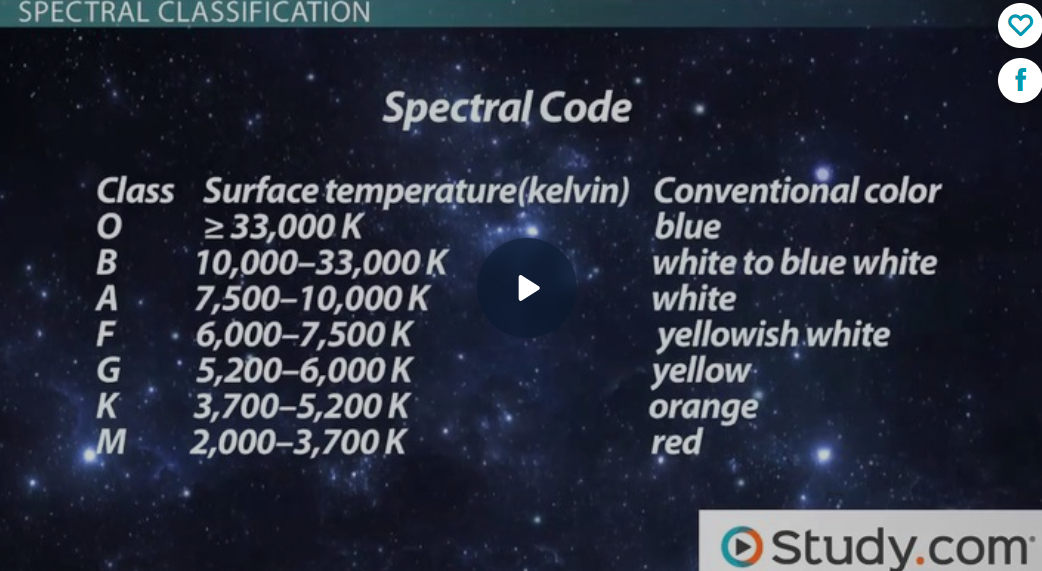

⚠️[!] 
1. Судя по получившимся названиям цветов, по их температуре в кельвинах и по найденной в интернете таблице - цвета в наших данных определны не совсем верно - например: 
`25,12990,8.5e-05,0.00984,12.23,2,Yellowish White`. В наших данных температура в кельвинах 12990, и указан цвет Yellowish White, в то время как цвет Yellowish White обязан укладываться в диапазон 6000-7500
2.  К тому же тип цвета, раз он даже определяется температурой по таблице - должен приводить к утечке целевого признака.

Посмотрим, какие диапазоны температуры соответствует какому типу цвета и сравним со скриншотом:

In [13]:
df.groupby('starcolor')['temperature_k'].agg(['min', 'median', 'mean', 'max']) \
    .round()

,min,median,mean,max
starcolor,,,,
blue,5752,19922.0,21918.0,40000
blue-white,8570,14100.0,16660.0,30000
orange,3749,4018.0,4018.0,4287
orange-red,5112,5112.0,5112.0,5112
pale-yellow-orange,7230,7230.0,7230.0,7230
red,1939,3324.0,3292.0,6850
white,7220,8880.0,9720.0,14732
white-yellow,7100,7100.0,7100.0,7100
whitish,8052,8876.0,8876.0,9700


Обнаруженные несоответствия:
- ⚠️blue: и среднее, и тем более минимум значительно меньше предела из скриншота >=33К 
- blue-white - 👌, хотя чуть нарушает нижний предел из скриншота
- orange - 👌
- ⚠️orange-red - должен быть в районе 3700, судя по скриншоту, но у нас он 5112
- ⚠️pale-yellow-orange - должен быть в районе 3700, судя по скриншоту, но у нас он 7230
- red - относительно 👌, хотя и нарушает нижний предел из скриншота
- white - относительно 👌, хотя и нарушает пределы из скриншота
- white-yellow - 👌
    - тут можно было бы рассмотерть объединение с yellow-white, но не будем там делать, т. к. разные диапазоны и градации довольно разнообразные - возможно, это всё же разные цвета
- whitish - 👌
- yellow-white - 👌
- ⚠️ yellowish - по цифрам ближе к orange
- ⚠️yellowish-white - сильно выше порогам 6000-7500 из скриншота

Итого в 5 из 12 типов цветов есть существенное несоответствие скриншоту. Это плохо.

~~Исходя из того, что данный признак, похоже, что собран не достаточно качественно, а также из того, что он может послужить причиной утечки целевого признака - данный признак принято решение убрать:~~

In [14]:
##v2 df = df.drop(['starcolor'], axis=1)

def starcolor_by_temperature_k (row):
    t = row['temperature_k']
    
    if t >= 33000: return "O"
    elif t >= 10000: return "B"
    elif t >= 7500: return "A"
    elif t >= 6000: return "F"
    elif t >= 5200: return "G"
    elif t >= 3700: return "K"
    else: return "M"

df['starcolor'] = df.apply(starcolor_by_temperature_k, axis=1) 

# Исследовательский анализ данных (EDA)

'⬇-------- столбец starcolor --------⬇'

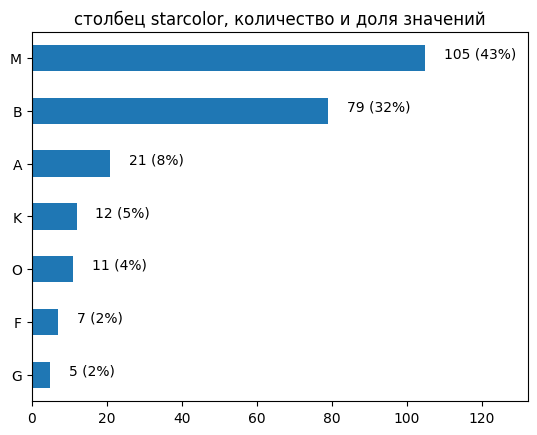

'⬇-------- Следующий признак: temperature_k --------⬇'

"фильтр = ''"

count      240.000000
mean     10497.462500
std       9552.425037
min       1939.000000
25%       3344.250000
50%       5776.000000
75%      15055.500000
max      40000.000000
Name: temperature_k, dtype: float64

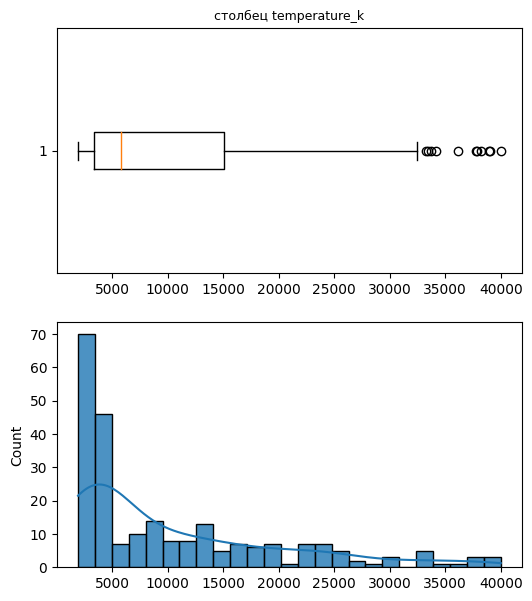

'⬇-------- Следующий признак: luminosity_l_lo --------⬇'

"фильтр = ''"

count       240.000000
mean     107188.361635
std      179432.244940
min           0.000080
25%           0.000865
50%           0.070500
75%      198050.000000
max      849420.000000
Name: luminosity_l_lo, dtype: float64

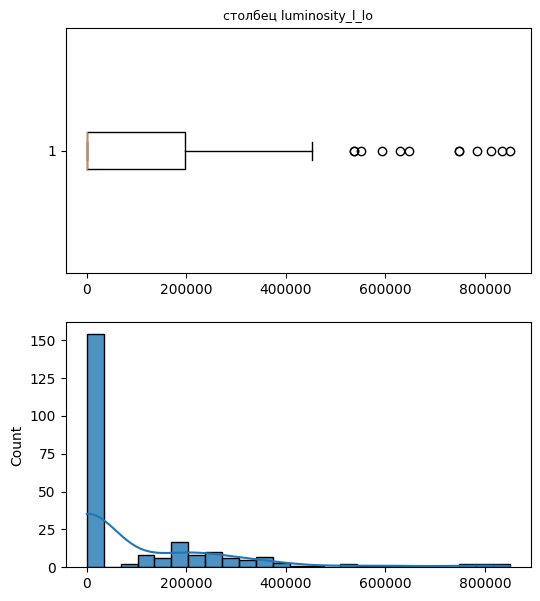

'⬇-------- Следующий признак: radius_r_ro --------⬇'

"фильтр = ''"

count     240.000000
mean      237.157781
std       517.155763
min         0.008400
25%         0.102750
50%         0.762500
75%        42.750000
max      1948.500000
Name: radius_r_ro, dtype: float64

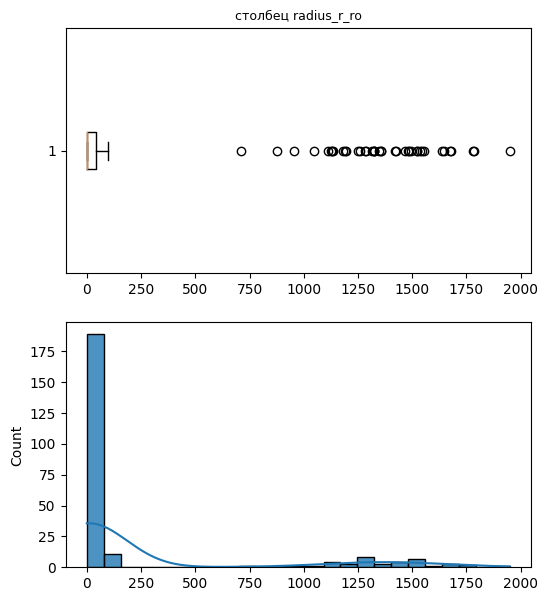

'⬇-------- Следующий признак: absolutemagnitude_mv --------⬇'

"фильтр = ''"

count    240.000000
mean       4.382396
std       10.532512
min      -11.920000
25%       -6.232500
50%        8.313000
75%       13.697500
max       20.060000
Name: absolutemagnitude_mv, dtype: float64

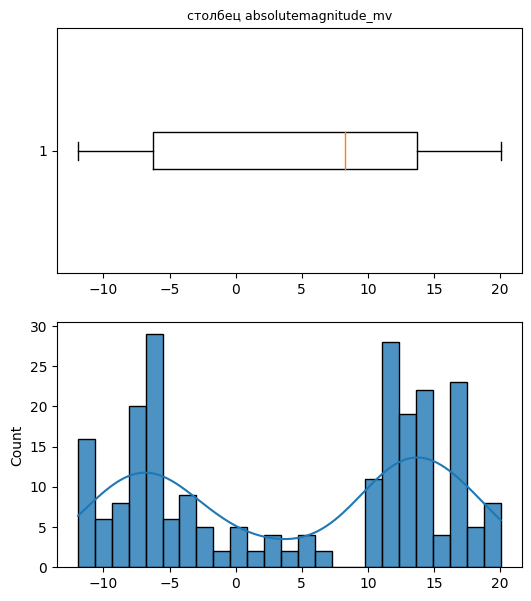

'⬇-------- Следующий признак: startype --------⬇'

"фильтр = ''"

count    240.000000
mean       2.500000
std        1.711394
min        0.000000
25%        1.000000
50%        2.500000
75%        4.000000
max        5.000000
Name: startype, dtype: float64

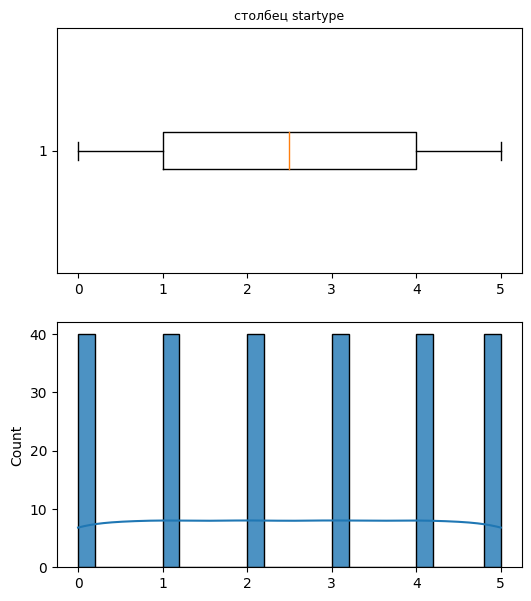

In [15]:
do_eda(df)

## Выводы и задачи по итогам EDA
- датасет так мал, что никакие выбросы удалять, похоже, что не стоит
- luminosity_l_lo
    - странно, что есть звёзды со свeтимостью звезды относительно солнца = 0, ведь это же звёзды, а не чёрные дыры, но.. возможно, так бывает
    - похоже на смесь распределений
- radius_r_ro 
    - опять же, странно, что есть свёзды с относительным радиусом = 0, но.. возможно, так бывает
    - похоже на смесь распределений
- absolutemagnitude_mv 
    - похоже на смесь двух распределений
- startype 
    - количество всех типов звёзд примерно одинаковое - возможно, данные собиралиь целенеправленно по стратам. Если так, то хорошо, что тренировочные данные представлены всеми стратами.
- starcolor 
    - лидеры: цвета "M" и "B"

# Проверим мультиколлинеарность

'Мультиколлинеарные фичи - претенденты для удаления:'

['absolutemagnitude_mv']

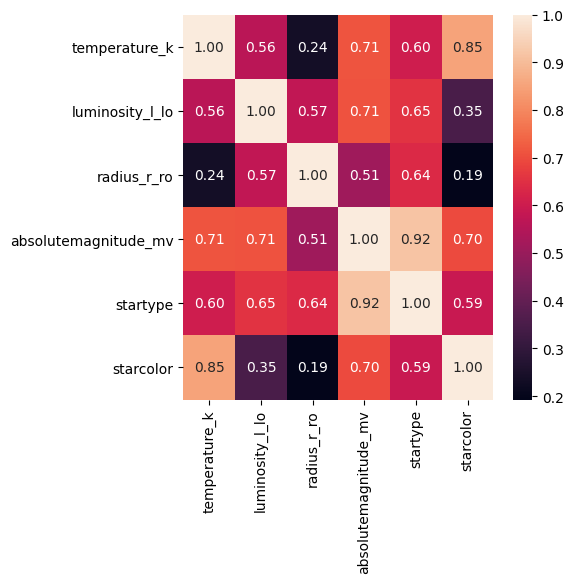

In [16]:
interval_cols=['temperature_k', 'luminosity_l_lo', 'radius_r_ro', 'absolutemagnitude_mv']
   
bins = {}
for c in interval_cols:
    bins[c] = 10;

_, ax = plt.subplots(figsize=(5,5))
ph_mx = df.phik_matrix(interval_cols=interval_cols, bins=bins)
sns.heatmap(ph_mx, annot=True, fmt='.2f', ax=ax);

columns_to_delete, ph_mx_no_mc = get_multicollinear_features (ph_mx)
display ("Мультиколлинеарные фичи - претенденты для удаления:")
display (columns_to_delete)

Из материалов Практикума:

*Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

Категориальных признака два: цвет и тип звезды. Чтобы не запутаться в цветах - рассмотрим их по отдельности:

Цвет звезды:

In [18]:
df['starcolor'].value_counts()

M    105
B     79
A     21
K     12
O     11
F      7
G      5
Name: starcolor, dtype: int64

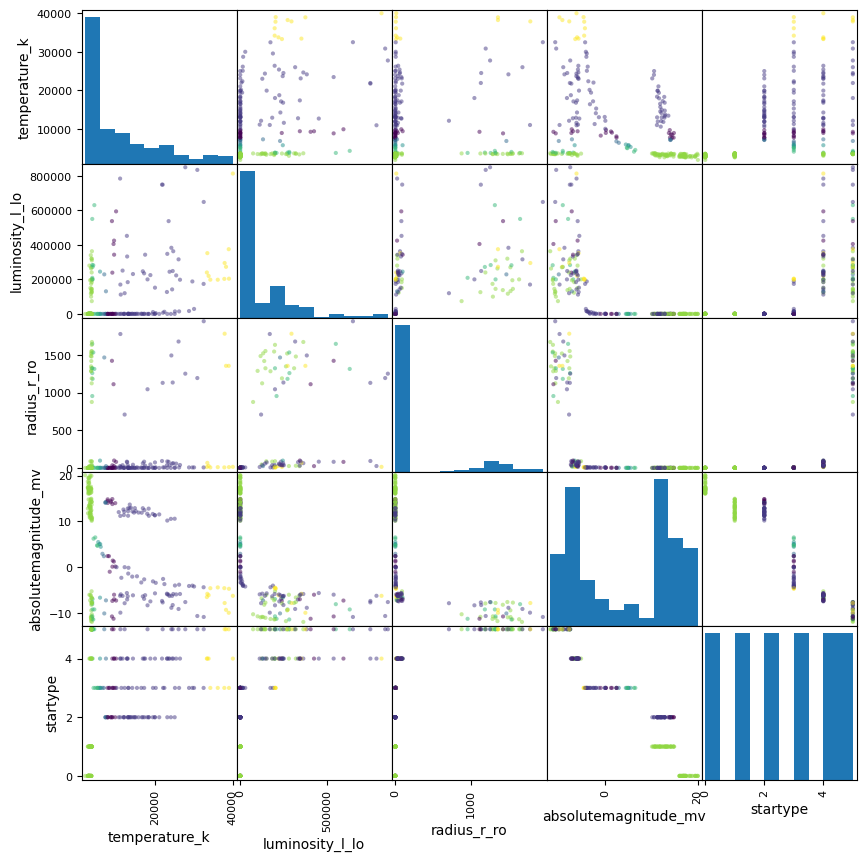

In [19]:
color_codes = df['starcolor'].astype('category').cat.codes

pd.plotting.scatter_matrix(df, c=color_codes, figsize=(10, 10));

# Разобъём выборку на тренировочную и тестовую

In [23]:
X = df.drop(['temperature_k'], axis=1)
y = df['temperature_k']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE,
    test_size=0.2, 
    shuffle=True,
    stratify=X['starcolor'])

# Масштабирование количественных данных

In [24]:
X_train

,luminosity_l_lo,radius_r_ro,absolutemagnitude_mv,startype,starcolor
125,0.000760,0.1210,19.630,0,M
168,342900.000000,30.0000,-6.090,4,B
1,0.000500,0.1542,16.600,0,M
236,834042.000000,1194.0000,-10.630,5,B
223,537430.000000,81.0000,-5.975,4,B
...,...,...,...,...,...
37,1.350000,0.9800,2.930,3,F
221,332520.000000,76.0000,-7.020,4,B
180,0.000231,0.0915,16.210,0,M
112,200000.000000,1635.0000,-11.330,5,M


In [25]:
num_col_names = ['luminosity_l_lo', 'radius_r_ro', 'absolutemagnitude_mv']
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = X_train.drop(num_col_names, axis=1).reset_index(drop=True)
X_test = X_test.drop(num_col_names, axis=1).reset_index(drop=True)


y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train = pd.concat([X_train, X_train_scaled], axis=1)
X_test = pd.concat([X_test, X_test_scaled], axis=1)

# кодирование категориальных признаков

In [26]:
ordered_cols = ['starcolor', 'startype']

encoder_ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# обучаем OrdinalEncoder на выбранных признаках из тренировочной выборки
# преобразовываем тренировочную выборку
X_train_ohe = encoder_ohe.fit_transform(X_train[ordered_cols])
X_test_ohe = encoder_ohe.transform(X_test[ordered_cols])

In [27]:
X_train_ohe = pd.DataFrame(X_train_ohe)
X_test_ohe = pd.DataFrame(X_test_ohe)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [28]:
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)
y_train = torch.FloatTensor(y_train.values)
y_test = torch.FloatTensor(y_test.values)

# Построение базовой нейронной сети

In [29]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, 
									n_hidden_neurons_2, n_out_neurons):
        super(Net, self).__init__()
			
        self.fc1 = nn.Linear (n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()
	
        self.fc2 = nn.Linear (n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear (n_hidden_neurons_2, n_out_neurons)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
			
        x = self.fc2(x)
        x = self.act2(x)
			
        x = self.fc3(x)
        return x

net = Net(14, 8, 4, 1) # инициализируйте нейронную сеть 

#print(net.forward(x)) # выведите результат прогонки тензора 

num_epochs = 20_000
optimizer = torch.optim.Adam(net.parameters(), lr=1.0e-2) 
loss = nn.MSELoss()

#X_train = torch.FloatTensor(X_train.values)
#X_test = torch.FloatTensor(X_test.values)
#y_train = torch.FloatTensor(y_train.values)
#y_test = torch.FloatTensor(y_test.values)

train_loss = []
test_loss = []

for epoch in range(num_epochs+1):
    net.train()

    optimizer.zero_grad()

    preds = net.forward(X_train).flatten()
    loss_value = loss(preds, y_train)
    loss_value.backward()
        
    optimizer.step()
    
    if epoch % 100 == 0:
        net.eval()
        test_pred = net.forward(X_test).flatten()
        test_rmse = round(np.sqrt(loss(test_pred, y_test).item()), 2)
        train_loss.append(round(np.sqrt(loss_value.item()), 2))
        test_loss.append(test_rmse)
        print(test_rmse)

14238.38
14124.54
12914.72
9870.0
6857.34
5286.51
4612.89
4267.93
4043.62
3884.27
3766.4
3675.72
3599.18
3542.98
3494.39
3457.77
3440.31
3441.07
3450.72
3464.26
3481.31
3495.13
3506.5
3515.47
3524.45
3534.02
3540.23
3545.64
3551.97
3559.76
3566.55
3570.67
3575.24
3579.18
3583.73
3587.28
3589.39
3590.44
3592.24
3599.55
3601.86
3602.71
3602.52
3599.82
3595.53
3562.54
3572.3
3577.22
3576.15
3578.49
3578.65
3575.64
3576.48
3579.59
3583.02
3575.6
3574.61
3586.76
3594.45
3600.87
3607.38
3606.49
3595.3
3596.53
3598.31
3582.28
3581.14
3547.81
3543.78
3542.0
3526.42
3527.89
3527.53
3531.9
3535.98
3539.61
3547.0
3555.9
3233.41
3179.46
3162.35
3151.84
3141.91
3128.78
3121.96
3107.08
3096.78
3088.87
3080.22
3068.73
3060.29
3056.78
3043.94
3041.04
3037.4
3030.49
3025.2
3018.02
3011.63
3005.74
3008.32
3007.15
3005.58
3006.56
3005.05
3001.16
3003.55
2995.3
2995.72
2998.8
2988.84
2990.1
2990.01
2987.48
2982.36
2986.15
2981.83
2980.75
2979.69
2979.78
2979.08
2976.35
2972.37
2975.2
2971.25
2968.8
2968.6

In [30]:
def plot_loss (train_loss, test_loss):
    plt.figure(figsize=(10,5))
    plt.title("Training and Validation Loss")
    plt.plot(train_loss, label="train")
    plt.plot(test_loss, label="test")
    plt.xlabel("iterations *1000")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

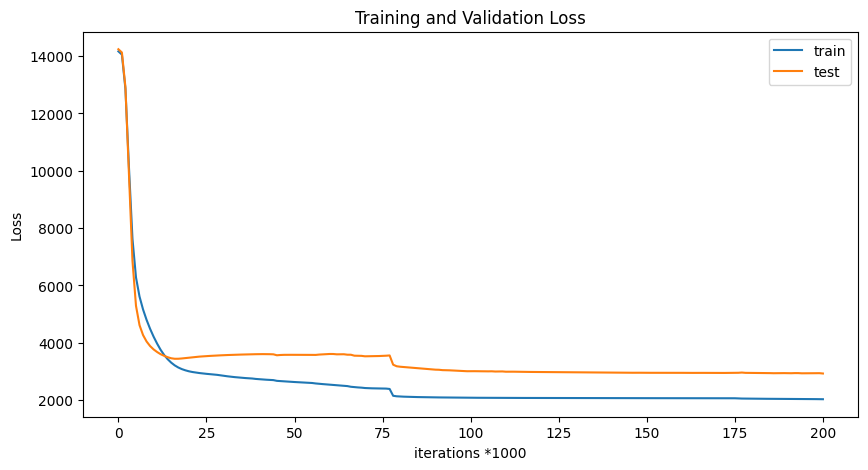

In [31]:
plot_loss (train_loss, test_loss)

In [32]:
display (f"минимальный rmse = {min(test_loss)}")

'минимальный rmse = 2926.44'

## Оценка качества

In [33]:
def draw_plots (test_pred, plot_test_pred):

    max_bars = 20
    plot_test_pred = test_pred.reshape(-1).tolist()[:max_bars]
    plot_test_true = y_test[:max_bars]
    plot_test_x = range(len(plot_test_pred))

    bar_width = 0.5
    fig, ax = plt.subplots()

    ax.bar(plot_test_x, plot_test_true, width=bar_width, align='edge',
                    label="true", color='g')
    ax.bar([(x + bar_width/4) for x in plot_test_x], plot_test_pred, width=bar_width/2, align='edge',
                    label="predictions", color='r')

    ax.set_xlabel('звёзды тестовой выборки')
    ax.set_ylabel('Абсолютная температура T(K)')
    ax.set_title('План-факт сравнение предсказаний модели на тестовой выборки')
    ax.legend()

    plt.show()

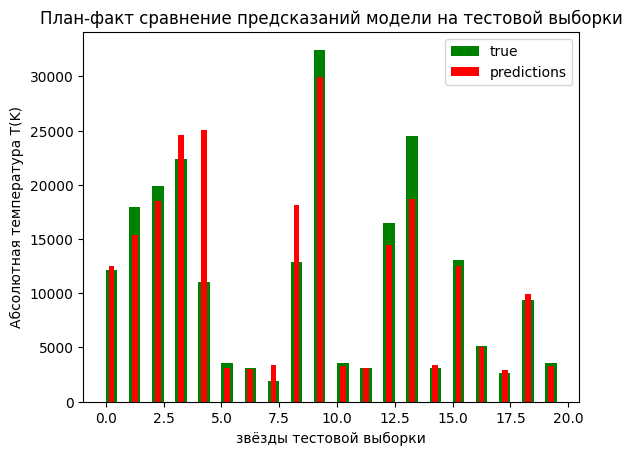

In [34]:
draw_plots (test_pred, y_test)

# Улучшение нейронной сети

In [35]:
class Net_v2(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, p1,
									n_hidden_neurons_2, n_out_neurons, p2):
        super(Net_v2, self).__init__()
        
        self.fc1 = nn.Linear (n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()
        self.dp1 = nn.Dropout(p=p1)
        
        self.fc2 = nn.Linear (n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()
        self.dp2 = nn.Dropout(p=p2)

        self.fc3 = nn.Linear (n_hidden_neurons_2, n_out_neurons)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.dp1(x)
			
        x = self.fc2(x)
        x = self.act2(x)
        x = self.dp2(x)
			
        x = self.fc3(x)
        return x

param_grid = {
    'lr': [1.0e-2, 1.0e-3],
    'batch_size': [20, 50],
    'p1': [0, 0.4],
    'p2': [0, 0.2]
}

grid = ParameterGrid(param_grid)
results = []

num_epochs = 5_000

for params in grid:

    net = Net_v2 (14, 8, params['p1'], 4, 1, params['p2'])

    batch_size = params['batch_size']
    num_batches = ceil(len(X_train)/batch_size)

    optimizer = torch.optim.Adam(net.parameters(), lr=params['lr']) 
    loss = nn.MSELoss()

    train_loss = []
    test_loss = []

    for epoch in range(num_epochs+1):
        net.train()
        order = np.random.permutation(len(X_train))
        for batch_idx in range(num_batches):
            start_index = batch_idx * batch_size

            optimizer.zero_grad()

            batch_indexes = order[start_index:start_index+batch_size]
            X_batch = X_train[batch_indexes]
            y_batch = y_train[batch_indexes]
        
            preds = net.forward(X_batch).flatten()
            loss_value = loss(preds, y_batch)
            loss_value.backward()
                
            optimizer.step()
            
            if epoch % 100 == 0:
                net.eval()
                test_pred = net.forward(X_test).flatten()
                test_rmse = round(np.sqrt(loss(test_pred, y_test).item()), 2)
                train_loss.append(round(np.sqrt(loss_value.item()), 2))
                test_loss.append(test_rmse)

    print(f"Testing: {params}")
    results.append({
        **params,
        'train_loss': train_loss,
        'test_loss': test_loss,
        'net': net,
        'test_pred': test_pred,
        'y_test': y_test
    })

Testing: {'batch_size': 20, 'lr': 0.01, 'p1': 0, 'p2': 0}
Testing: {'batch_size': 20, 'lr': 0.01, 'p1': 0, 'p2': 0.2}
Testing: {'batch_size': 20, 'lr': 0.01, 'p1': 0.4, 'p2': 0}
Testing: {'batch_size': 20, 'lr': 0.01, 'p1': 0.4, 'p2': 0.2}
Testing: {'batch_size': 20, 'lr': 0.001, 'p1': 0, 'p2': 0}
Testing: {'batch_size': 20, 'lr': 0.001, 'p1': 0, 'p2': 0.2}
Testing: {'batch_size': 20, 'lr': 0.001, 'p1': 0.4, 'p2': 0}
Testing: {'batch_size': 20, 'lr': 0.001, 'p1': 0.4, 'p2': 0.2}
Testing: {'batch_size': 50, 'lr': 0.01, 'p1': 0, 'p2': 0}
Testing: {'batch_size': 50, 'lr': 0.01, 'p1': 0, 'p2': 0.2}
Testing: {'batch_size': 50, 'lr': 0.01, 'p1': 0.4, 'p2': 0}
Testing: {'batch_size': 50, 'lr': 0.01, 'p1': 0.4, 'p2': 0.2}
Testing: {'batch_size': 50, 'lr': 0.001, 'p1': 0, 'p2': 0}
Testing: {'batch_size': 50, 'lr': 0.001, 'p1': 0, 'p2': 0.2}
Testing: {'batch_size': 50, 'lr': 0.001, 'p1': 0.4, 'p2': 0}
Testing: {'batch_size': 50, 'lr': 0.001, 'p1': 0.4, 'p2': 0.2}


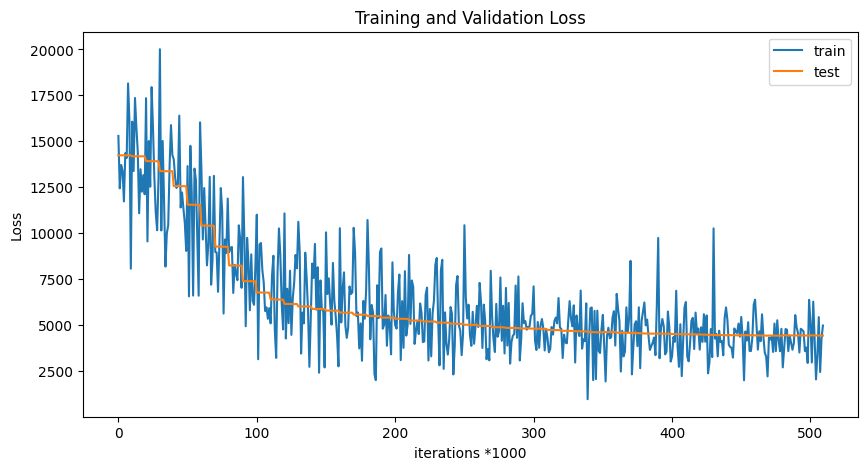

'минимальный rmse = 4428.39'

'лучшие параметры модели: batch_size: 20, lr: 0.001, p1: 0, p2: 0.2'

In [36]:
best_run = min(results, key=lambda x: x['test_loss'])
best_model = best_run['net']

plot_loss (best_run['train_loss'], best_run['test_loss'])
display (f"минимальный rmse = {min(best_run['test_loss'])}")
display (f"лучшие параметры модели: batch_size: {best_run['batch_size']}, lr: {best_run['lr']}, p1: {best_run['p1']}, p2: {best_run['p2']}")

## Оценка качества

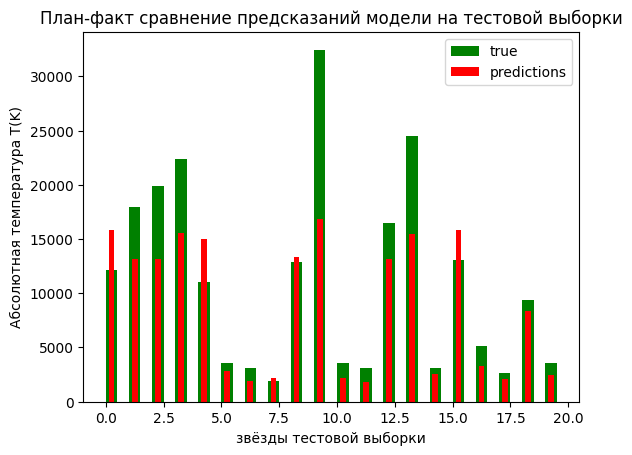

In [37]:
draw_plots (best_run['test_pred'], best_run['y_test'])

# Выводы

- В соответствии с поставленной задачей(см. первый раздел)
    - была проведена подготовка данных и их разведочный анализ, в результате которых:
        - удалены явные и неявные дубликаты (исправлен признак starcolor), удален признак startype для устранения мультиколлинеарности
    - была натренирована базовая модель с **2926**, что удовлетворяет **цель** $RMSE \leq 4500$
    - также была натренирована модель с перебором гиперпараметров (но с меньшим количеством эпох). Она показала rmse **4428**, что удовлетворяет **цель** $RMSE \leq 4500$ (при количестве эпох 20000 как в базовой модели - она должна показать rmse не хуже 2926).